# 01 — Exploratory Data Analysis (Credit Risk Lens)

This is not generic EDA. Every chart and table is framed through a **credit risk** perspective —
default rates by segment, bureau signal analysis, and missing-data governance.

**Dataset:** Home Credit Default Risk (307,511 applications, 8% default rate)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

%matplotlib inline

## 1. Load Data

In [2]:
app = pd.read_csv("../data/raw/application_train.csv")
print(f"Shape: {app.shape}")
print(f"Default rate: {app['TARGET'].mean():.2%}")
app.head()

Shape: (307511, 122)
Default rate: 8.07%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Default Rate by Key Segments

Build a proper **risk segmentation table** — the kind you'd present at a credit committee.

In [3]:
# Age bands
app["AGE_YEARS"] = (-app["DAYS_BIRTH"]) / 365.25
app["AGE_BAND"] = pd.cut(app["AGE_YEARS"], bins=[18, 25, 35, 45, 55, 65, 100],
                          labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

# Income bands
app["INCOME_BAND"] = pd.qcut(app["AMT_INCOME_TOTAL"], q=5,
                              labels=["Very Low", "Low", "Medium", "High", "Very High"])

# Loan-to-income ratio
app["LOAN_INCOME_RATIO"] = app["AMT_CREDIT"] / (app["AMT_INCOME_TOTAL"] + 1)
app["LTI_BAND"] = pd.qcut(app["LOAN_INCOME_RATIO"], q=5,
                           labels=["Very Low", "Low", "Medium", "High", "Very High"])

In [4]:
# Risk segmentation table
segments = ["AGE_BAND", "INCOME_BAND", "NAME_CONTRACT_TYPE",
            "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_HOUSING_TYPE", "LTI_BAND"]

for seg in segments:
    tbl = (
        app.groupby(seg)["TARGET"]
        .agg(["count", "sum", "mean"])
        .rename(columns={"count": "N", "sum": "Defaults", "mean": "Default_Rate"})
        .sort_values("Default_Rate", ascending=False)
    )
    tbl["Default_Rate"] = tbl["Default_Rate"].map("{:.2%}".format)
    print(f"\n{'='*50}")
    print(f"  Default Rate by {seg}")
    print(f"{'='*50}")
    print(tbl.to_string())


  Default Rate by AGE_BAND
              N  Defaults Default_Rate
AGE_BAND                              
18-25     12233      1504       12.29%
26-35     72429      7721       10.66%
36-45     84261      7085        8.41%
46-55     70190      4946        7.05%
56-65     60522      3281        5.42%
65+        7876       288        3.66%

  Default Rate by INCOME_BAND
                 N  Defaults Default_Rate
INCOME_BAND                              
Medium       35453      3079        8.68%
Low          85756      7365        8.59%
Very Low     63671      5225        8.21%
High         75513      6084        8.06%
Very High    47118      3072        6.52%

  Default Rate by NAME_CONTRACT_TYPE
                         N  Defaults Default_Rate
NAME_CONTRACT_TYPE                               
Cash loans          278232     23221        8.35%
Revolving loans      29279      1604        5.48%

  Default Rate by NAME_INCOME_TYPE
                           N  Defaults Default_Rate
NAME_INCO

C:\Users\Eric\AppData\Local\Temp\ipykernel_21532\827425484.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  app.groupby(seg)["TARGET"]
C:\Users\Eric\AppData\Local\Temp\ipykernel_21532\827425484.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  app.groupby(seg)["TARGET"]
C:\Users\Eric\AppData\Local\Temp\ipykernel_21532\827425484.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  app.groupby(seg)["TARGET"]


## 3. Bureau & Delinquency Signals

C:\Users\Eric\AppData\Local\Temp\ipykernel_21532\64926953.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  app_bureau.groupby("bureau_band")["TARGET"].mean().plot.bar(ax=axes[0], color="steelblue")


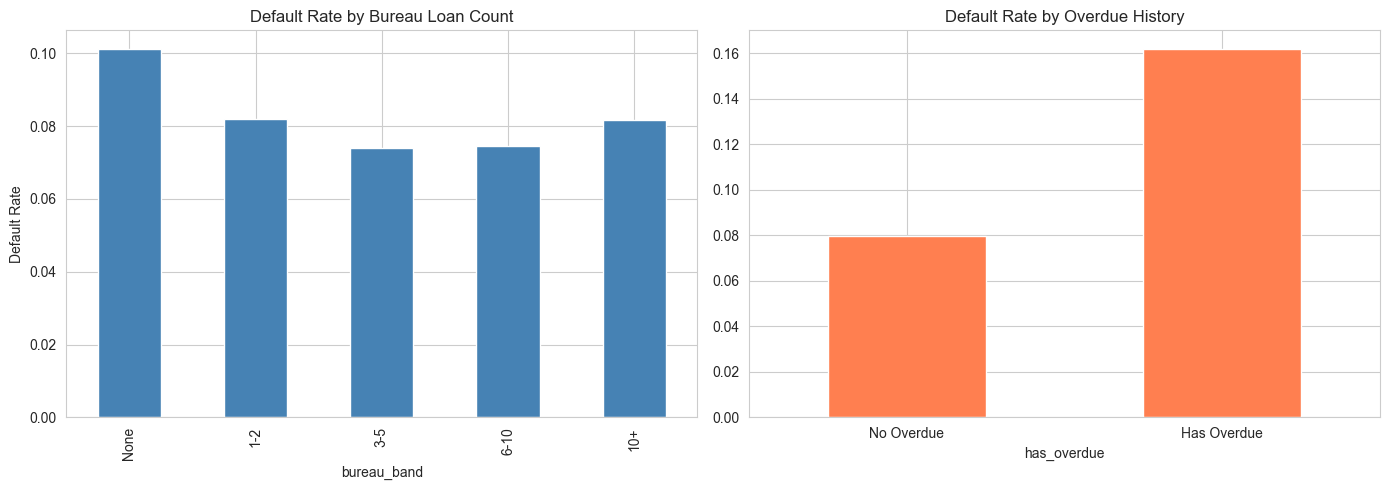

In [5]:
bureau = pd.read_csv("../data/raw/bureau.csv")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_count=("SK_ID_BUREAU", "count"),
    active_credits=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    total_overdue=("AMT_CREDIT_SUM_OVERDUE", "sum"),
).reset_index()

app_bureau = app.merge(bureau_agg, on="SK_ID_CURR", how="left")

# Default rate by bureau loan count
app_bureau["bureau_band"] = pd.cut(app_bureau["bureau_count"].fillna(0),
                                    bins=[-1, 0, 2, 5, 10, 100],
                                    labels=["None", "1-2", "3-5", "6-10", "10+"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app_bureau.groupby("bureau_band")["TARGET"].mean().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Default Rate by Bureau Loan Count")
axes[0].set_ylabel("Default Rate")

app_bureau["has_overdue"] = (app_bureau["total_overdue"].fillna(0) > 0).astype(int)
app_bureau.groupby("has_overdue")["TARGET"].mean().plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Default Rate by Overdue History")
axes[1].set_xticklabels(["No Overdue", "Has Overdue"], rotation=0)

plt.tight_layout()
plt.show()

## 4. Missing Data Analysis (Model Governance Exercise)

Document which features have >30% missing, hypothesize **why** they're missing
(MCAR vs MAR vs MNAR), and document imputation decisions.

Features with missing values: 67
Features with >30% missing: 50



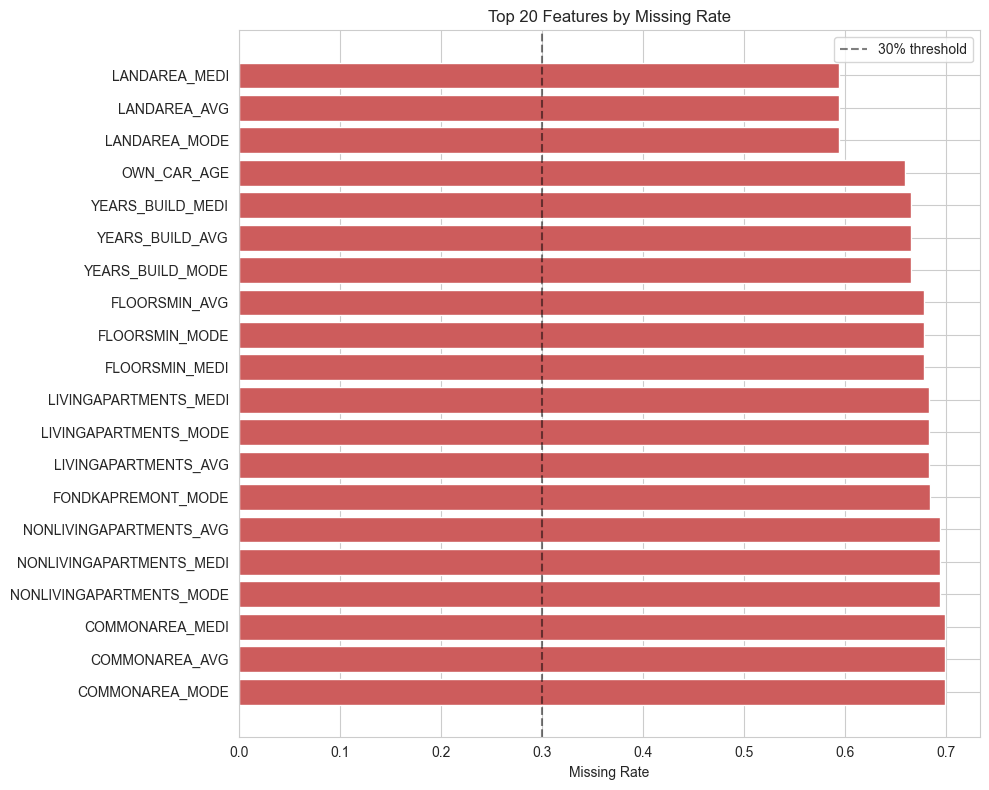

In [6]:
missing = (
    app.isnull().mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature", 0: "Missing_Rate"})
)
missing = missing[missing["Missing_Rate"] > 0]
missing["Missing_Pct"] = missing["Missing_Rate"].map("{:.1%}".format)

print(f"Features with missing values: {len(missing)}")
print(f"Features with >30% missing: {(missing['Missing_Rate'] > 0.3).sum()}")
print()

# Visualize top 20
fig, ax = plt.subplots(figsize=(10, 8))
top_missing = missing.head(20)
ax.barh(top_missing["Feature"], top_missing["Missing_Rate"], color="indianred")
ax.set_xlabel("Missing Rate")
ax.set_title("Top 20 Features by Missing Rate")
ax.axvline(x=0.3, color="black", linestyle="--", alpha=0.5, label="30% threshold")
ax.legend()
plt.tight_layout()
plt.show()

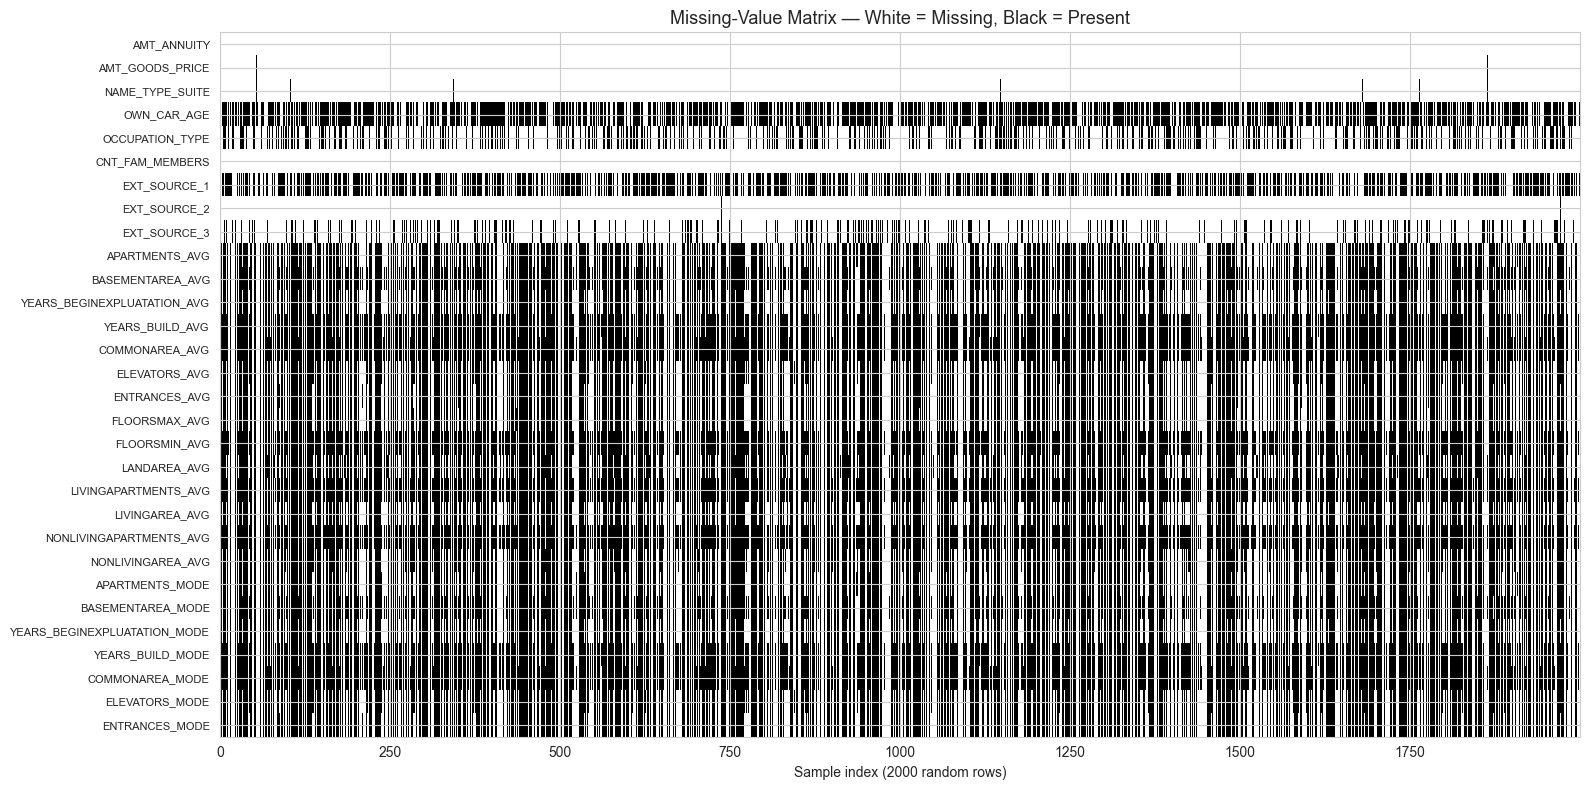


Features with >50% missing: 41
Features with >30% missing: 50
Total features with any missing: 67 / 127


In [7]:
# Missing-value matrix visualization (missingno-style using matplotlib)
# Shows pattern of missingness across features — co-missing features suggest MNAR
cols_with_missing = app.columns[app.isnull().any()].tolist()[:30]  # top 30 for readability
sample = app[cols_with_missing].sample(min(2000, len(app)), random_state=42)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(sample.isnull().values.T, aspect='auto', cmap='gray_r', interpolation='none')
ax.set_yticks(range(len(cols_with_missing)))
ax.set_yticklabels(cols_with_missing, fontsize=8)
ax.set_xlabel('Sample index (2000 random rows)')
ax.set_title('Missing-Value Matrix — White = Missing, Black = Present', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFeatures with >50% missing: {(app.isnull().mean() > 0.5).sum()}")
print(f"Features with >30% missing: {(app.isnull().mean() > 0.3).sum()}")
print(f"Total features with any missing: {app.isnull().any().sum()} / {app.shape[1]}")

### Missing Data Hypotheses & Imputation Strategy

| Feature Group | Missing Rate | Hypothesis | Imputation |
|---|---|---|---|
| `COMMONAREA_*`, `BASEMENTAREA_*`, etc. | ~47–70% | MNAR — only collected for certain housing types | Flag + median |
| `EXT_SOURCE_*` | 0–60% | MAR — depends on data vendor coverage | Median (high IV) |
| `OWN_CAR_AGE` | ~34% | MCAR — only for car owners | Flag + 0 |
| `OCCUPATION_TYPE` | ~31% | MAR — not always captured at application | Mode + "Unknown" |
| `AMT_REQ_CREDIT_BUREAU_*` | ~13% | MAR — no bureau file exists | 0 (no enquiries) |

## 5. Class Imbalance Documentation

**Observed default rate: ~8%**

Strategy: Use `class_weight='balanced'` for logistic regression and `scale_pos_weight` for XGBoost.
Prefer threshold adjustment over SMOTE to avoid synthetic noise in production.

**Business rationale:** A bank cares more about *recall on defaults* (catching bad loans)
than overall accuracy. A 92% accuracy model that just predicts "good" for everyone is useless.

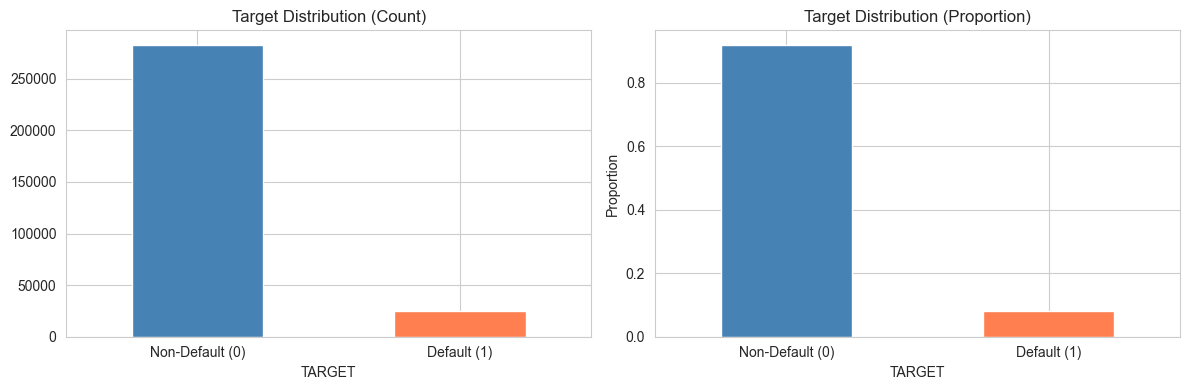


Imbalance ratio: 1:11
scale_pos_weight for XGBoost: 11.4


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

app["TARGET"].value_counts().plot.bar(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Target Distribution (Count)")
axes[0].set_xticklabels(["Non-Default (0)", "Default (1)"], rotation=0)

app["TARGET"].value_counts(normalize=True).plot.bar(ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Target Distribution (Proportion)")
axes[1].set_xticklabels(["Non-Default (0)", "Default (1)"], rotation=0)
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: 1:{int((app['TARGET']==0).sum() / (app['TARGET']==1).sum())}")
print(f"scale_pos_weight for XGBoost: {(app['TARGET']==0).sum() / (app['TARGET']==1).sum():.1f}")

## 6. Key Correlations with Target

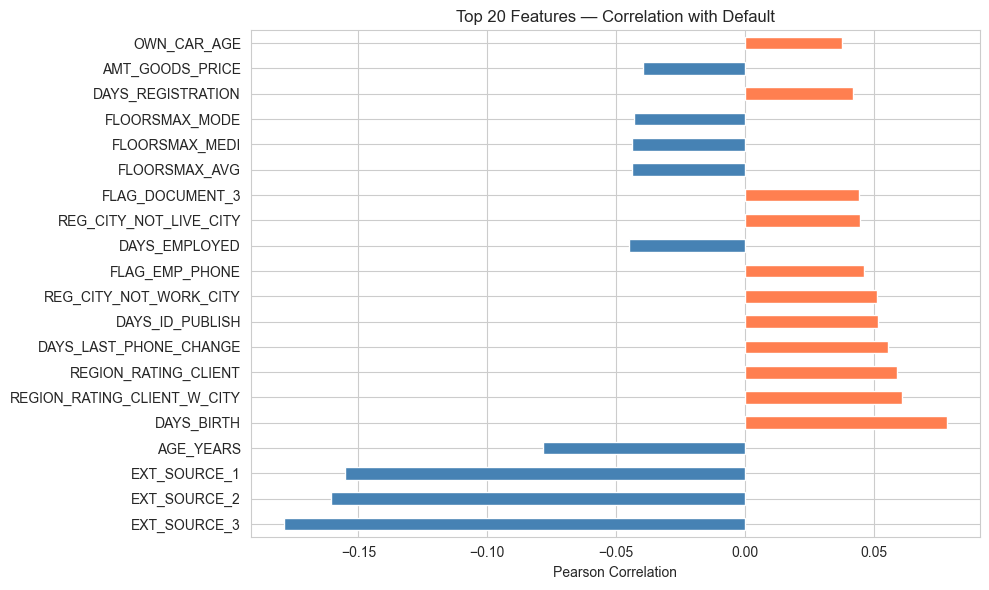

In [9]:
# Correlation with TARGET for numeric features
numeric_corr = (
    app.select_dtypes(include="number")
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
numeric_corr.plot.barh(ax=ax, color=numeric_corr.apply(lambda x: "coral" if x > 0 else "steelblue"))
ax.set_title("Top 20 Features — Correlation with Default")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

## Correlation Heatmap — Top Numeric Features

Inter-feature correlations reveal multicollinearity risks for logistic regression. Highly correlated features should be flagged before WoE encoding.

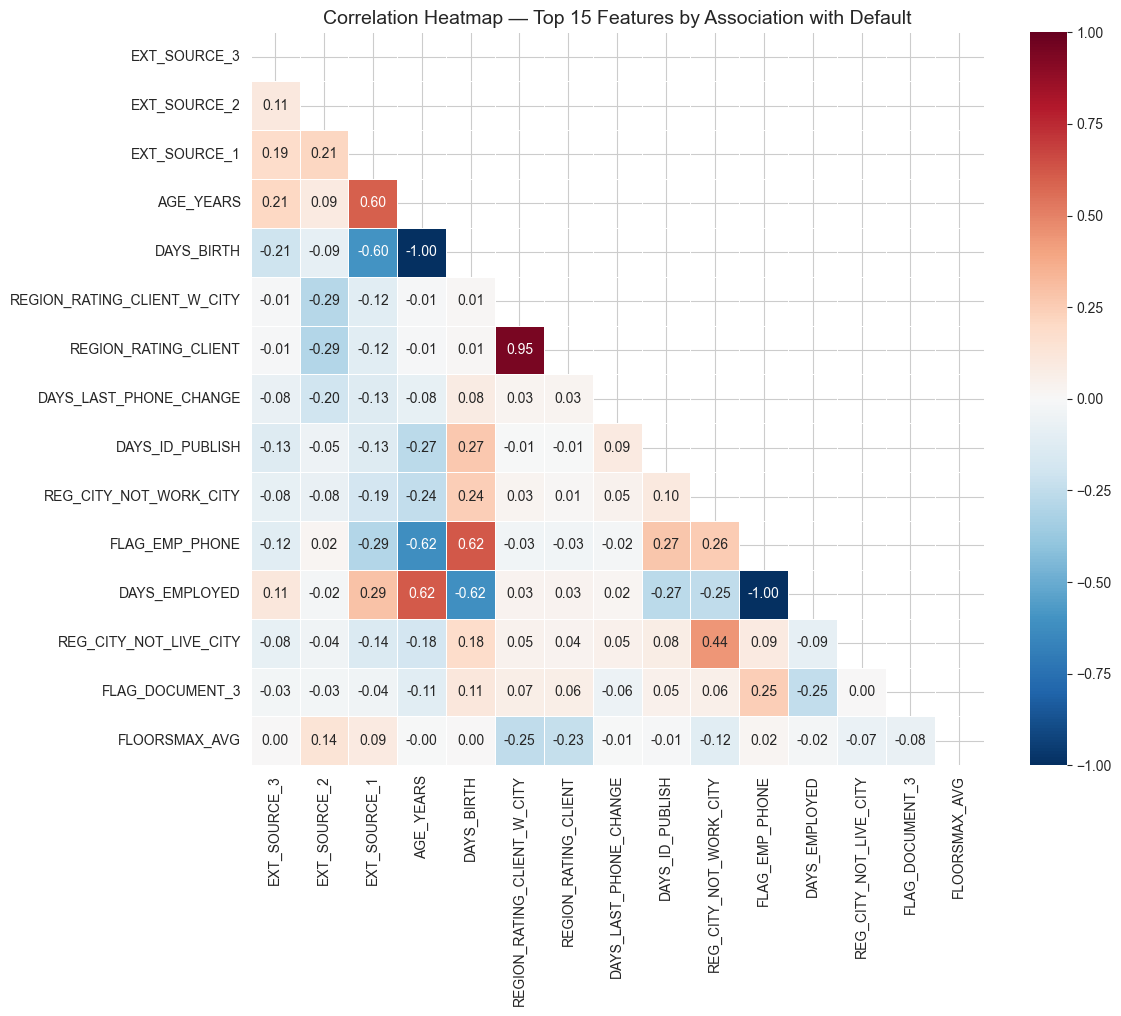

Highly correlated feature pairs (|r| > 0.7):
   AGE_YEARS <-> DAYS_BIRTH: r = -1.0
   REGION_RATING_CLIENT_W_CITY <-> REGION_RATING_CLIENT: r = 0.951
   FLAG_EMP_PHONE <-> DAYS_EMPLOYED: r = -1.0


In [10]:
# Correlation heatmap of top 15 numeric features (by absolute correlation with TARGET)
top_features = app.select_dtypes(include='number').corr()['TARGET'].abs().sort_values(ascending=False).index[1:16]
corr_matrix = app[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Top 15 Features by Association with Default', fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7) for VIF review
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              round(corr_matrix.iloc[i, j], 3)))
if high_corr:
    print("Highly correlated feature pairs (|r| > 0.7):")
    for f1, f2, r in high_corr:
        print(f"   {f1} <-> {f2}: r = {r}")
else:
    print("No feature pairs exceed |r| > 0.7 threshold.")

## EXT_SOURCE Distributions by Default Status

External data sources (EXT_SOURCE_1, 2, 3) are consistently the strongest predictors in Home Credit data. Their distributions, split by TARGET, demonstrate clear class separation — exactly what credit scorecards exploit.

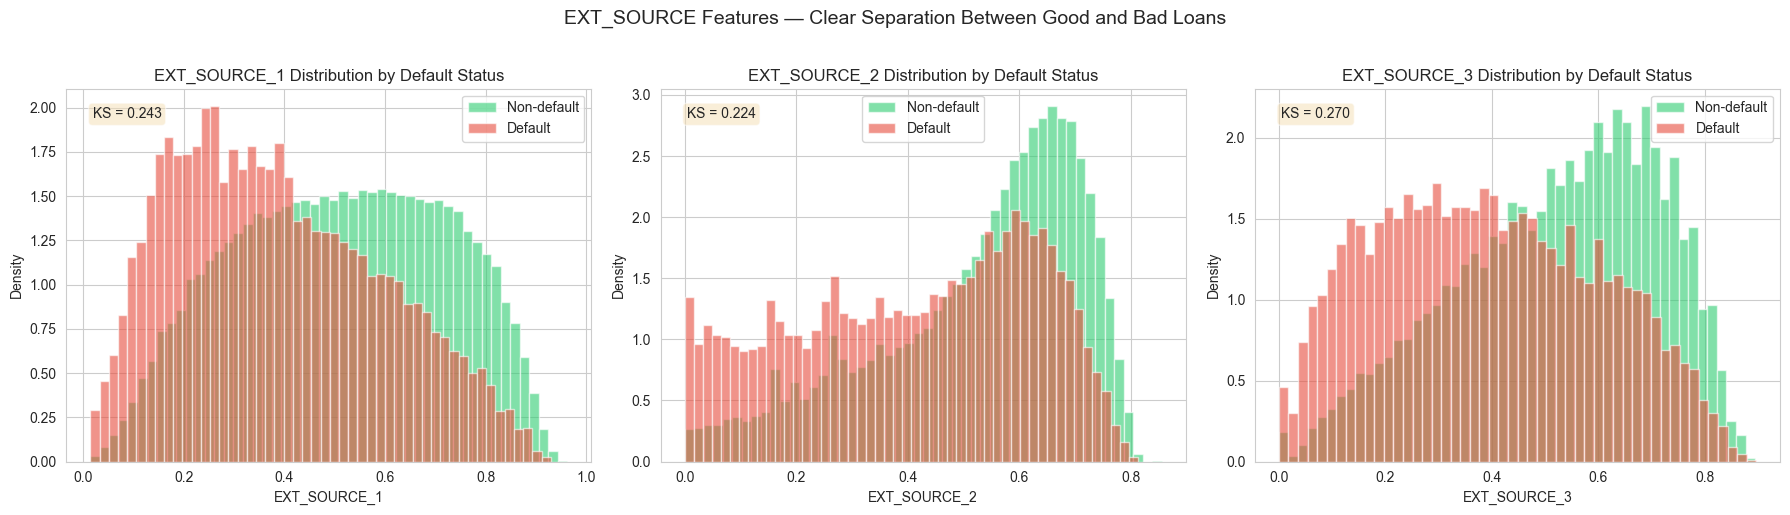

EXT_SOURCE_1: 56.4% missing — significant missingness
EXT_SOURCE_2: 0.2% missing — acceptable
EXT_SOURCE_3: 19.8% missing — acceptable


In [11]:
# EXT_SOURCE distributions split by TARGET
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(ext_cols):
    for target_val, label, color in [(0, 'Non-default', '#2ecc71'), (1, 'Default', '#e74c3c')]:
        subset = app[app['TARGET'] == target_val][col].dropna()
        axes[i].hist(subset, bins=50, alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(f'{col} Distribution by Default Status', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

    # KS statistic between classes
    from scipy import stats
    good = app[app['TARGET'] == 0][col].dropna()
    bad = app[app['TARGET'] == 1][col].dropna()
    ks_stat, p_val = stats.ks_2samp(good, bad)
    axes[i].annotate(f'KS = {ks_stat:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                     fontsize=10, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('EXT_SOURCE Features — Clear Separation Between Good and Bad Loans', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Missing rates for EXT_SOURCE
for col in ext_cols:
    pct = app[col].isna().mean() * 100
    print(f"{col}: {pct:.1f}% missing — {'significant missingness' if pct > 30 else 'acceptable'}")